
STEP 2: EDA


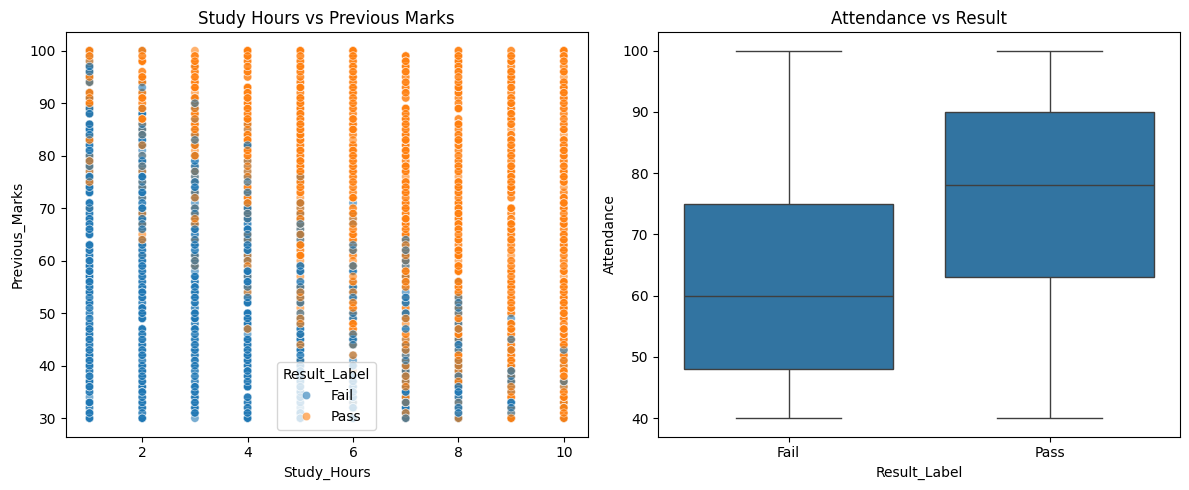

EDA plots saved as eda_analysis.png

MODEL PERFORMANCE
Logistic Regression  Accuracy: 0.9917
Decision Tree        Accuracy: 0.9367
Random Forest        Accuracy: 0.9717
SVM                  Accuracy: 0.9883

BEST MODEL: Logistic Regression
ACCURACY: 0.9917

Enter Student Details:


Study Hours (0–12):  7
Attendance % (0–100):  54
Previous Marks (0–100):  54



----- RESULT -----
Prediction       : FAIL ❌
Pass Probability : 25.94%
------------------


In [5]:
# ============================================================
# STUDENT PERFORMANCE PREDICTION SYSTEM (FINAL)
# ============================================================

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

# ─────────────────────────────────────────────────────────────
# STEP 1: LOAD DATA
# ─────────────────────────────────────────────────────────────
df = pd.read_csv("student_performance_3000.csv")
df.head()

# Convert target
df['Final_Result'] = df['Final_Result'].map({'Pass': 1, 'Fail': 0})

# ─────────────────────────────────────────────────────────────
# STEP 2: EDA (Exploratory Data Analysis)
# ─────────────────────────────────────────────────────────────
print("Plotting Graph")

df_eda = df.copy()
df_eda['Result_Label'] = df_eda['Final_Result'].map({1: 'Pass', 0: 'Fail'})

plt.figure(figsize=(12, 5))

# Plot 1: Study Hours vs Previous Marks
plt.subplot(1, 2, 1)
sns.scatterplot(
    x='Study_Hours',
    y='Previous_Marks',
    hue='Result_Label',
    data=df_eda,
    alpha=0.6
)
plt.title("Study Hours vs Previous Marks")

# Plot 2: Attendance vs Result
plt.subplot(1, 2, 2)
sns.boxplot(
    x='Result_Label',
    y='Attendance',
    data=df_eda
)
plt.title("Attendance vs Result")

plt.tight_layout()
plt.savefig("eda_analysis.png")
plt.show()

print("EDA plots saved as eda_analysis.png")

# ─────────────────────────────────────────────────────────────
# STEP 3: FEATURE SELECTION
# ─────────────────────────────────────────────────────────────
FEATURES = ['Study_Hours', 'Attendance', 'Previous_Marks']

X = df[FEATURES]
y = df['Final_Result']

# ─────────────────────────────────────────────────────────────
# STEP 4: PREPROCESSING
# ─────────────────────────────────────────────────────────────
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# ─────────────────────────────────────────────────────────────
# STEP 5: TRAIN-TEST SPLIT + SCALING
# ─────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ─────────────────────────────────────────────────────────────
# STEP 6: MODEL TRAINING
# ─────────────────────────────────────────────────────────────
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(probability=True)
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

# ─────────────────────────────────────────────────────────────
# STEP 7: MODEL EVALUATION
# ─────────────────────────────────────────────────────────────
best_model = None
best_accuracy = 0

print("\nMODEL PERFORMANCE")
print("=" * 40)

for name, model in trained_models.items():
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name:<20} Accuracy: {acc:.4f}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_name = name

print("\nBEST MODEL:", best_name)
print("ACCURACY:", round(best_accuracy, 4))

# ─────────────────────────────────────────────────────────────
# STEP 8: USER INPUT PREDICTION
# ─────────────────────────────────────────────────────────────
def predict_student():
    print("\nEnter Student Details:")

    try:
        study_hours = float(input("Study Hours (0–12): "))
        attendance = float(input("Attendance % (0–100): "))
        previous_marks = float(input("Previous Marks (0–100): "))

        data = pd.DataFrame([[study_hours, attendance, previous_marks]],
                            columns=FEATURES)

        data = imputer.transform(data)
        data = scaler.transform(data)

        prob = best_model.predict_proba(data)[0][1]
        result = "PASS ✅" if prob >= 0.5 else "FAIL ❌"

        print("\n----- RESULT -----")
        print(f"Prediction       : {result}")
        print(f"Pass Probability : {prob:.2%}")
        print("------------------")

    except:
        print("Invalid input! Please enter numeric values.")

# ─────────────────────────────────────────────────────────────
# RUN PREDICTION
# ─────────────────────────────────────────────────────────────
predict_student()

In [ ]:
# ============================================================
# STUDENT PERFORMANCE PREDICTION SYSTEM (FINAL)
# ============================================================

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

# ─────────────────────────────────────────────────────────────
# STEP 1: LOAD DATA
# ─────────────────────────────────────────────────────────────
df = pd.read_csv("student_performance_3000.csv")
df.head()

# Convert target
df['Final_Result'] = df['Final_Result'].map({'Pass': 1, 'Fail': 0})

# ─────────────────────────────────────────────────────────────
# STEP 2: EDA (Exploratory Data Analysis)
# ─────────────────────────────────────────────────────────────
print("Plotting Graph")

df_eda = df.copy()
df_eda['Result_Label'] = df_eda['Final_Result'].map({1: 'Pass', 0: 'Fail'})

plt.figure(figsize=(12, 5))

# Plot 1: Study Hours vs Previous Marks
plt.subplot(1, 2, 1)
sns.scatterplot(
    x='Study_Hours',
    y='Previous_Marks',
    hue='Result_Label',
    data=df_eda,
    alpha=0.6
)
plt.title("Study Hours vs Previous Marks")

# Plot 2: Attendance vs Result
plt.subplot(1, 2, 2)
sns.boxplot(
    x='Result_Label',
    y='Attendance',
    data=df_eda
)
plt.title("Attendance vs Result")

plt.tight_layout()
plt.savefig("eda_analysis.png")
plt.show()

print("EDA plots saved as eda_analysis.png")

# ─────────────────────────────────────────────────────────────
# STEP 3: FEATURE SELECTION
# ─────────────────────────────────────────────────────────────
FEATURES = ['Study_Hours', 'Attendance', 'Previous_Marks']

X = df[FEATURES]
y = df['Final_Result']

# ─────────────────────────────────────────────────────────────
# STEP 4: PREPROCESSING
# ─────────────────────────────────────────────────────────────
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# ─────────────────────────────────────────────────────────────
# STEP 5: TRAIN-TEST SPLIT + SCALING
# ─────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ─────────────────────────────────────────────────────────────
# STEP 6: MODEL TRAINING
# ─────────────────────────────────────────────────────────────
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(probability=True)
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

# ─────────────────────────────────────────────────────────────
# STEP 7: MODEL EVALUATION
# ─────────────────────────────────────────────────────────────
best_model = None
best_accuracy = 0

print("\nMODEL PERFORMANCE")
print("=" * 40)

for name, model in trained_models.items():
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name:<20} Accuracy: {acc:.4f}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_name = name

print("\nBEST MODEL:", best_name)
print("ACCURACY:", round(best_accuracy, 4))

# ─────────────────────────────────────────────────────────────
# STEP 8: USER INPUT PREDICTION
# ─────────────────────────────────────────────────────────────
def predict_student():
    print("\nEnter Student Details:")

    try:
        study_hours = float(input("Study Hours (0–12): "))
        attendance = float(input("Attendance % (0–100): "))
        previous_marks = float(input("Previous Marks (0–100): "))

        data = pd.DataFrame([[study_hours, attendance, previous_marks]],
                            columns=FEATURES)

        data = imputer.transform(data)
        data = scaler.transform(data)

        prob = best_model.predict_proba(data)[0][1]
        result = "PASS ✅" if prob >= 0.5 else "FAIL ❌"

        print("\n----- RESULT -----")
        print(f"Prediction       : {result}")
        print(f"Pass Probability : {prob:.2%}")
        print("------------------")

    except:
        print("Invalid input! Please enter numeric values.")

# ─────────────────────────────────────────────────────────────
# RUN PREDICTION
# ─────────────────────────────────────────────────────────────
predict_student()